# 🦋 Redes Neuronales y Teoría de la Información: Neural Network Coding (NNC)

### ¿Qué es Neural Network Coding (NNC)?
Tradicionalmente, las comunicaciones digitales separan la codificación de fuente (compresión) y la codificación de canal (protección contra errores) usando el Teorema de Separación de Shannon. Sin embargo, en redes complejas, este teorema deja de ser óptimo. NNC propone reemplazar los codificadores y decodificadores tradicionales por **Redes Neuronales Internas (inner NNs)** entrenadas de manera conjunta (End-to-End).

En esta práctica, simularemos una transmisión de imágenes de forma "one-shot" (transmisión analógica directa en lugar de cuantización clásica) sobre un canal ruidoso.

### La Red Mariposa (Butterfly Network)
Imaginemos que tenemos dos nodos fuente ($S_1, S_2$), un nodo intermedio o *relay* ($R$), y dos nodos destino ($D_1, D_2$).

**Objetivo:** Ambos destinos ($D_1$ y $D_2$) quieren reconstruir la imagen **completa** del MNIST (784 px), pero las fuentes $S_1$ y $S_2$ solo observan una mitad de la imagen cada una (392 px). El Relay $R$ ayuda combinando de forma no lineal (usando una NN) las señales ruidosas que recibe.



## 1. Definición de Capas del Canal Físico
Usaremos un canal **AWGN (Ruido Blanco Gaussiano Aditivo)** y una capa de **Normalización de Potencia** que garantiza que la energía promedio de la señal transmitida $W$ cumpla con la restricción: $\mathbb{E}[W^2] \le P$.


In [ ]:
# Importación de librerías base para tensores y redes neuronales
import torch
import torch.nn as nn
import torch.optim as optim
# Utilidades de visión computacional para cargar y transformar el dataset MNIST
from torchvision import datasets, transforms
# Librerías para visualización gráfica y operaciones matemáticas estándar
import matplotlib.pyplot as plt
import numpy as np

# Configuración de hardware: detecta automáticamente si hay una GPU (CUDA) disponible
# para acelerar los cálculos masivos de tensores; de lo contrario, usa el procesador (CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

class PowerNormalization(nn.Module):
    """
    Capa personalizada para garantizar la restricción de potencia física del transmisor.
    Asegura que la energía promedio de los símbolos transmitidos sea exactamente P.
    """
    def __init__(self, P=1.0):
        super().__init__()
        self.P = P  # Potencia objetivo (por defecto P=1.0)

    def forward(self, x):
        # 1. Calculamos la potencia promedio (E[x^2]) a lo largo de la dimensión del código (dim=1).
        # keepdim=True mantiene la forma del tensor para permitir el broadcasting en la división.
        power = torch.mean(x**2, dim=1, keepdim=True)

        # 2. Normalizamos 'x' dividiendo por su amplitud (raíz cuadrada de la potencia)
        # y luego multiplicamos por la raíz de la potencia objetivo P.
        # El '+ 1e-8' es un épsilon minúsculo que previene el error matemático de dividir por cero.
        return (x / torch.sqrt(power + 1e-8)) * np.sqrt(self.P)

class AWGNChannel(nn.Module):
    """
    Capa que simula un canal de comunicación con Ruido Blanco Gaussiano Aditivo (AWGN).
    Al usar funciones de PyTorch, el ruido se añade de forma diferenciable,
    lo que permite que el gradiente fluya durante el entrenamiento End-to-End.
    """
    def __init__(self, snr_db):
        super().__init__()
        self.snr_db = snr_db  # Relación Señal a Ruido (SNR) expresada en decibelios (dB)

    def forward(self, x):
        # Si no se define un SNR, asumimos un canal ideal (sin ruido) y devolvemos la señal intacta
        if self.snr_db is None:
            return x

        # Convertimos el SNR de su escala logarítmica (dB) a escala lineal para los cálculos
        snr_linear = 10 ** (self.snr_db / 10.0)

        # Matemáticamente: SNR = Potencia_Señal / Varianza_Ruido.
        # Como nuestra capa previa (PowerNormalization) fijó la Potencia_Señal en 1.0,
        # despejamos y obtenemos que la Varianza_Ruido = 1.0 / SNR_lineal.
        noise_var = 1.0 / snr_linear

        # Generamos un tensor de ruido gaussiano (media 0, varianza 1) con la misma forma que 'x'.
        # Lo multiplicamos por la desviación estándar (raíz cuadrada de la varianza) para escalar su energía.
        noise = torch.randn_like(x) * np.sqrt(noise_var)

        # La señal que llega al receptor es la suma de la señal transmitida más el ruido del canal
        return x + noise


Usando dispositivo: cuda


## 2. Construcción del Grafo y las "Inner NNs"
Definimos los nodos transmisores, el relay y los receptores.


In [ ]:
# Dimensión del vector latente (símbolos analógicos) que viajará por cada enlace físico.
# Estamos comprimiendo 392 píxeles a solo 16 números reales.
CODE_LENGTH = 16

class SourceNode(nn.Module):
    """
    Nodo Transmisor (S1 o S2). Implementa Joint Source-Channel Coding (JSCC)
    comprimiendo la imagen y modulándola simultáneamente para el canal.
    """
    def __init__(self):
        super().__init__()
        # Red neuronal interna (Inner NN) que extrae las características relevantes.
        # Entrada: 392 píxeles -> Capa oculta: 128 -> Salida: 32 símbolos (16 x 2)
        self.encoder = nn.Sequential(
            nn.Linear(392, 128), nn.ReLU(),
            nn.Linear(128, CODE_LENGTH * 2)
        )
        self.power_norm = PowerNormalization(P=1.0)

    def forward(self, x):
        out = self.encoder(x)
        # Dividimos el tensor de salida por la mitad usando slicing de PyTorch.
        # Los primeros 16 símbolos se enviarán al Relay, los otros 16 directamente al Destino.
        # Aplicamos la normalización física a cada flujo independiente.
        out_relay = self.power_norm(out[:, :CODE_LENGTH])
        out_dest = self.power_norm(out[:, CODE_LENGTH:])
        return out_relay, out_dest

class RelayNode(nn.Module):
    """
    Nodo Intermedio (R). A diferencia de los enrutadores clásicos que decodifican bits,
    este nodo recibe señales analógicas con ruido y las combina de forma no lineal (Compute-and-Forward).
    """
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(CODE_LENGTH * 2, 128), nn.ReLU(),
            nn.Linear(128, CODE_LENGTH * 2)
        )
        self.power_norm = PowerNormalization(P=1.0)

    def forward(self, y_s1, y_s2):
        # Concatenamos las señales ruidosas provenientes de S1 y S2 a lo largo de las columnas (dim=1)
        x_in = torch.cat([y_s1, y_s2], dim=1)
        # La red procesa la interferencia y genera una nueva representación conjunta
        out = self.network(x_in)

        # Separa y normaliza la energía para los dos enlaces salientes (hacia D1 y D2)
        out_d1 = self.power_norm(out[:, :CODE_LENGTH])
        out_d2 = self.power_norm(out[:, CODE_LENGTH:])
        return out_d1, out_d2

class DestinationNode(nn.Module):
    """
    Nodo Receptor (D1 o D2). Actúa como el decodificador final.
    Debe reconstruir la imagen original a partir de dos flujos de información corrompidos por ruido.
    """
    def __init__(self):
        super().__init__()
        self.decoder = nn.Sequential(
            nn.Linear(CODE_LENGTH * 2, 256), nn.ReLU(),
            nn.Linear(256, 784),
            # Sigmoid mapea cualquier valor real al rango [0, 1], lo cual es
            # matemáticamente idóneo para representar la intensidad de un píxel.
            nn.Sigmoid()
        )

    def forward(self, y_source, y_relay):
        # Recolecta la diversidad espacial: la señal directa de la fuente y la señal procesada por el relay
        x_in = torch.cat([y_source, y_relay], dim=1)
        return self.decoder(x_in)

class ButterflyNetwork(nn.Module):
    """
    Grafo maestro computacional. Conecta físicamente las entidades y define las fases de transmisión.
    Esta clase permite que el gradiente de error fluya desde los destinos hasta las fuentes durante el entrenamiento.
    """
    def __init__(self, snr_db):
        super().__init__()
        # Instanciamos la topología: 2 Fuentes, 1 Relay, 2 Destinos
        self.s1, self.s2 = SourceNode(), SourceNode()
        self.relay = RelayNode()
        self.d1, self.d2 = DestinationNode(), DestinationNode()
        # Definimos el medio físico de transmisión con su respectivo nivel de ruido
        self.channel = AWGNChannel(snr_db)

    def forward(self, x1, x2):
        # --- FASE 1: Transmisión desde las fuentes ---
        # S1 y S2 procesan sus respectivas mitades de imagen
        x_s1_r, x_s1_d1 = self.s1(x1)
        x_s2_r, x_s2_d2 = self.s2(x2)

        # Las señales viajan por el canal físico adquiriendo ruido blanco gaussiano (AWGN)
        y_r_from_s1, y_r_from_s2 = self.channel(x_s1_r), self.channel(x_s2_r)
        y_d1_from_s1, y_d2_from_s2 = self.channel(x_s1_d1), self.channel(x_s2_d2)

        # --- FASE 2: Intervención del Relay ---
        # El relay procesa matemáticamente la superposición de señales que recibió
        x_r_d1, x_r_d2 = self.relay(y_r_from_s1, y_r_from_s2)

        # Las señales emitidas por el relay también sufren degradación en el canal hacia los destinos
        y_d1_from_r, y_d2_from_r = self.channel(x_r_d1), self.channel(x_r_d2)

        # --- FASE 3: Decodificación Final ---
        # D1 y D2 utilizan las señales recibidas en la Fase 1 y en la Fase 2 para estimar la imagen
        out_d1 = self.d1(y_d1_from_s1, y_d1_from_r)
        out_d2 = self.d2(y_d2_from_s2, y_d2_from_r)

        return out_d1, out_d2

## 3. Preparación de Datos (Dataset MNIST)
Dividimos cada imagen a la mitad (392px para S1, 392px para S2).


In [ ]:
# Transformaciones de datos: ToTensor() convierte las imágenes de formato PIL (píxeles 0-255)
# a tensores matemáticos de PyTorch, normalizando automáticamente sus valores al rango [0.0, 1.0].
transform = transforms.Compose([transforms.ToTensor()])

# Descargamos los conjuntos de datos oficiales de MNIST (imágenes de dígitos del 0 al 9).
# train=True carga el set de entrenamiento; train=False carga el set de validación.
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Para que el entrenamiento sea rápido en computadoras básicas,
# extraemos un subconjunto de solo 6,000 imágenes (el 10% del total).
train_subset = torch.utils.data.Subset(train_dataset, range(6000))

# DataLoader empaqueta las imágenes en lotes (batches) para procesarlas en paralelo.
# shuffle=True es crucial en entrenamiento para que la red no memorice el orden de las imágenes.
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)

def prepare_batch(images):
    """
    Adapta el lote de imágenes a la topología física de nuestra Red Mariposa.
    """
    # Aplana el tensor: transforma la matriz 2D de píxeles [batch, 28, 28]
    # en un vector 1D de [batch, 784] para poder alimentarlo a las capas lineales (densas).
    images = images.view(images.size(0), -1)

    # Simula la separación espacial de la información:
    # La Fuente 1 (S1) solo tiene acceso a la mitad superior de la imagen (392 píxeles).
    # La Fuente 2 (S2) solo tiene acceso a la mitad inferior (392 píxeles).
    x1, x2 = images[:, :392], images[:, 392:]

    # Retorna los fragmentos para cada transmisor y la imagen original completa,
    # la cual servirá como "Ground Truth" o target para medir el error de reconstrucción.
    return x1, x2, images

100%|██████████| 9.91M/9.91M [00:00<00:00, 31.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 806kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 6.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.5MB/s]


## 4. Entrenamiento End-to-End


In [ ]:
# Instanciamos la red completa y la enviamos a la memoria del dispositivo (CPU/GPU).
# Configuramos el canal físico interno para un régimen moderado de ruido (SNR = 10 dB).
model = ButterflyNetwork(snr_db=10.0).to(device)

# Función de pérdida: Error Cuadrático Medio (MSE).
# Matemáticamente, penaliza las diferencias de intensidad píxel por píxel
# entre la imagen original y la imagen reconstruida en los destinos.
criterion = nn.MSELoss()

# Optimizador Adam: actualiza los pesos de las redes neuronales basándose en los gradientes.
# lr=1e-3 es la tasa de aprendizaje (qué tan grandes son los pasos en la optimización).
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Número de veces que el algoritmo procesará el dataset completo.
epochs = 50

print("Iniciando entrenamiento...")
for epoch in range(epochs):
    # Ponemos el modelo en modo entrenamiento (necesario para rastrear gradientes)
    model.train()
    total_loss = 0

    # Iteramos sobre los lotes de datos. Ignoramos las etiquetas reales ('_')
    # porque nuestro objetivo no es clasificar el dígito, sino reconstruir los píxeles.
    for images, _ in train_loader:
        # Movemos los tensores a la memoria de la tarjeta gráfica (si está disponible)
        images = images.to(device)

        # Preparamos los datos: dividimos la imagen para las dos fuentes y guardamos el target
        x1, x2, target = prepare_batch(images)

        # 1. Limpiamos los gradientes acumulados de la iteración anterior
        optimizer.zero_grad()

        # 2. FORWARD PASS (Propagación hacia adelante)
        # La señal viaja por toda la red de extremo a extremo: S1/S2 -> Canal -> Relay -> Canal -> D1/D2.
        # Las funciones de ruido son diferenciables, permitiendo este cálculo.
        out_d1, out_d2 = model(x1, x2)

        # 3. CÁLCULO DEL ERROR JOINT (Conjunto)
        # Sumamos el error de ambos nodos destino para que la red aprenda a ayudar a ambos simultáneamente.
        loss = criterion(out_d1, target) + criterion(out_d2, target)

        # 4. BACKWARD PASS (Retropropagación)
        # Aplica la regla de la cadena (cálculo diferencial) desde el error final
        # fluyendo hacia atrás por las capas de ruido, el relay y hasta las fuentes.
        loss.backward()

        # 5. ACTUALIZACIÓN DE PESOS
        # El optimizador ajusta los parámetros de las redes internas para minimizar el MSE.
        optimizer.step()

        # Acumulamos el valor escalar del error para mostrar el progreso
        total_loss += loss.item()

    # Al final de cada época, imprimimos el error promedio del lote
    print(f"Época [{epoch+1}/{epochs}], MSE Loss Promedio: {total_loss/len(train_loader):.4f}")

Iniciando entrenamiento...
Época [1/50], MSE Loss Promedio: 0.1481
Época [2/50], MSE Loss Promedio: 0.0740
Época [3/50], MSE Loss Promedio: 0.0582
Época [4/50], MSE Loss Promedio: 0.0517
Época [5/50], MSE Loss Promedio: 0.0475
Época [6/50], MSE Loss Promedio: 0.0447
Época [7/50], MSE Loss Promedio: 0.0425
Época [8/50], MSE Loss Promedio: 0.0409
Época [9/50], MSE Loss Promedio: 0.0396
Época [10/50], MSE Loss Promedio: 0.0383
Época [11/50], MSE Loss Promedio: 0.0373
Época [12/50], MSE Loss Promedio: 0.0363
Época [13/50], MSE Loss Promedio: 0.0355
Época [14/50], MSE Loss Promedio: 0.0348
Época [15/50], MSE Loss Promedio: 0.0342
Época [16/50], MSE Loss Promedio: 0.0336
Época [17/50], MSE Loss Promedio: 0.0332
Época [18/50], MSE Loss Promedio: 0.0328
Época [19/50], MSE Loss Promedio: 0.0323
Época [20/50], MSE Loss Promedio: 0.0319
Época [21/50], MSE Loss Promedio: 0.0315
Época [22/50], MSE Loss Promedio: 0.0313
Época [23/50], MSE Loss Promedio: 0.0309
Época [24/50], MSE Loss Promedio: 0.030

## 5. Evaluación y Visualización


SNR = 20.0 dB | MSE D1: 0.0112


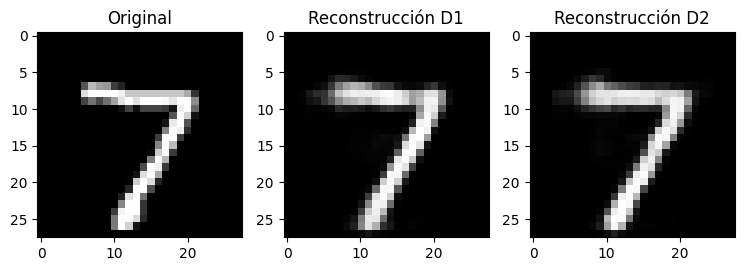

SNR = 10.0 dB | MSE D1: 0.0140


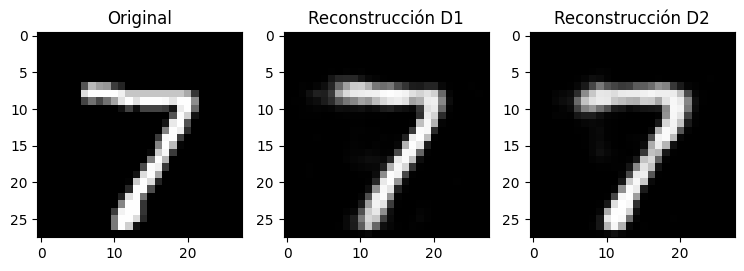

SNR = 5.0 dB | MSE D1: 0.0226


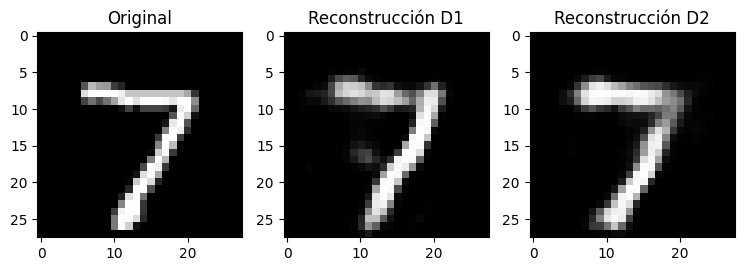

SNR = 0.0 dB | MSE D1: 0.0455


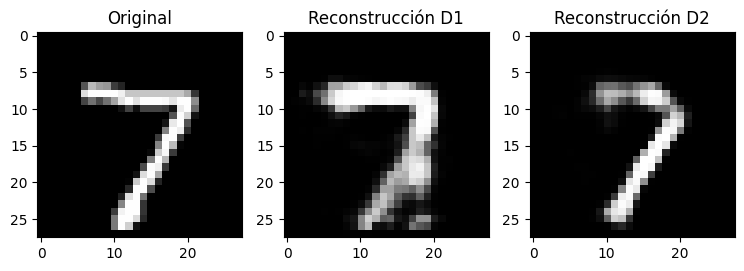

In [ ]:
def evaluate_and_plot(model, test_loader, snr_test):
    """
    Evalúa la robustez del esquema NNC alterando el nivel de ruido del canal en tiempo de inferencia.
    Esto demuestra la degradación "grácil" (graceful degradation) característica del
    Joint Source-Channel Coding frente al colapso abrupto (cliff effect) de las comunicaciones clásicas.
    """
    # Sobrescribimos el nivel de ruido del canal dinámicamente para someter la red a estrés
    model.channel.snr_db = snr_test

    # Ponemos el modelo en modo evaluación (desactiva actualizaciones de Dropout/BatchNorm si existieran)
    model.eval()

    # Desactivamos el motor de cálculo diferencial (autograd) de PyTorch.
    # Al no calcular gradientes, ahorramos memoria de video y aceleramos la ejecución.
    with torch.no_grad():
        # Extraemos un único lote (batch) de imágenes del conjunto de prueba (datos nunca antes vistos)
        images, _ = next(iter(test_loader))
        images = images.to(device)

        # Separamos las mitades espaciales para los transmisores y guardamos la imagen completa como target
        x1, x2, target = prepare_batch(images)

        # Realizamos la transmisión end-to-end a través del canal ruidoso
        out_d1, out_d2 = model(x1, x2)

        # Cuantificamos el daño en la señal calculando el Error Cuadrático Medio en el receptor 1
        mse_d1 = nn.MSELoss()(out_d1, target).item()
        print(f"SNR = {snr_test} dB | MSE D1: {mse_d1:.4f}")

        # --- Visualización Cualitativa (Matplotlib) ---
        fig, axes = plt.subplots(1, 3, figsize=(9, 3))

        # Extraemos el primer elemento del lote (índice 0), lo enviamos al procesador (CPU),
        # lo convertimos a un arreglo de NumPy y lo reestructuramos a una matriz visual 2D de 28x28 píxeles.
        axes[0].imshow(target[0].cpu().numpy().reshape(28,28), cmap='gray')
        axes[0].set_title("Original")

        # Mostramos la reconstrucción inferida por la red neuronal en el Destino 1
        axes[1].imshow(out_d1[0].cpu().numpy().reshape(28,28), cmap='gray')
        axes[1].set_title("Reconstrucción D1")

        # Mostramos la reconstrucción inferida por la red neuronal en el Destino 2
        axes[2].imshow(out_d2[0].cpu().numpy().reshape(28,28), cmap='gray')
        axes[2].set_title("Reconstrucción D2")

        plt.show()

# Ejecutamos un barrido paramétrico probando el mismo modelo exacto bajo diferentes
# regímenes termodinámicos: Excelente (20 dB), Moderado (10 dB), Pobre (5 dB) y Crítico (0 dB).
for snr in [20.0, 10.0, 5.0,  0.0]:
    evaluate_and_plot(model, test_loader, snr)